<a href="https://colab.research.google.com/github/vellsant/BrentOilPrice/blob/main/TechChallenge4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.model_selection import train_test_split

!pip install statsforecast

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive,SeasonalWindowAverage, AutoARIMA



from prophet import Prophet

In [96]:
df = pd.read_csv('/content/Dados_IPEA.csv')

Inicialmente, importamos o arquivo do IPEA e tratamos seus dados para podermos seguir com a análise e o forecasting.
Convertemos a coluna 'Data' para o tipo DateTime, e a definimos como index do dataframe.
Também realizamos tratamento na coluna 'Preco' para que os números possam ter o tipo Float.

In [97]:
df = df.dropna()
df['Data'] = pd.to_datetime(df['Data'])
df['Preco'] = df['Preco'].str.replace(',', '.')
df['Preco'] = df['Preco'].astype(np.float64)
df=df.set_index('Data')
df.head()

/tmp/ipython-input-2597263792.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Data'] = pd.to_datetime(df['Data'])


,Preco
Data,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


Como podemos ver, os tipos de dados do dataframe foram ajustados:

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11469 entries, 1987-05-20 to 2025-07-21
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Preco   11469 non-null  float64
dtypes: float64(1)
memory usage: 179.2 KB


Ao plotar um gráfico simples do preço do petróleo em relação ao tempo, podemos identificar preliminarmente momentos de alta e queda que já podem nos trazer primeiros insights em relação aos dados.

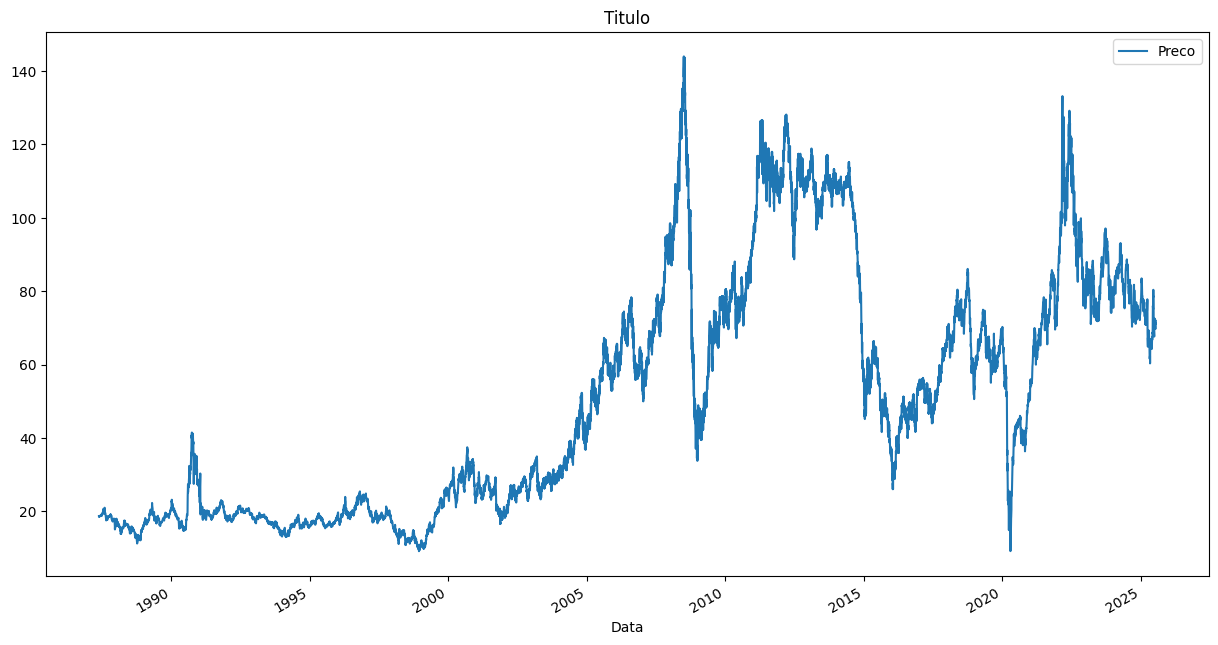

In [99]:
df.plot(title = 'Titulo', figsize=(15,8))
plt.show()

Seguindo como nossa análise, realizamos a decomposição sazonal.

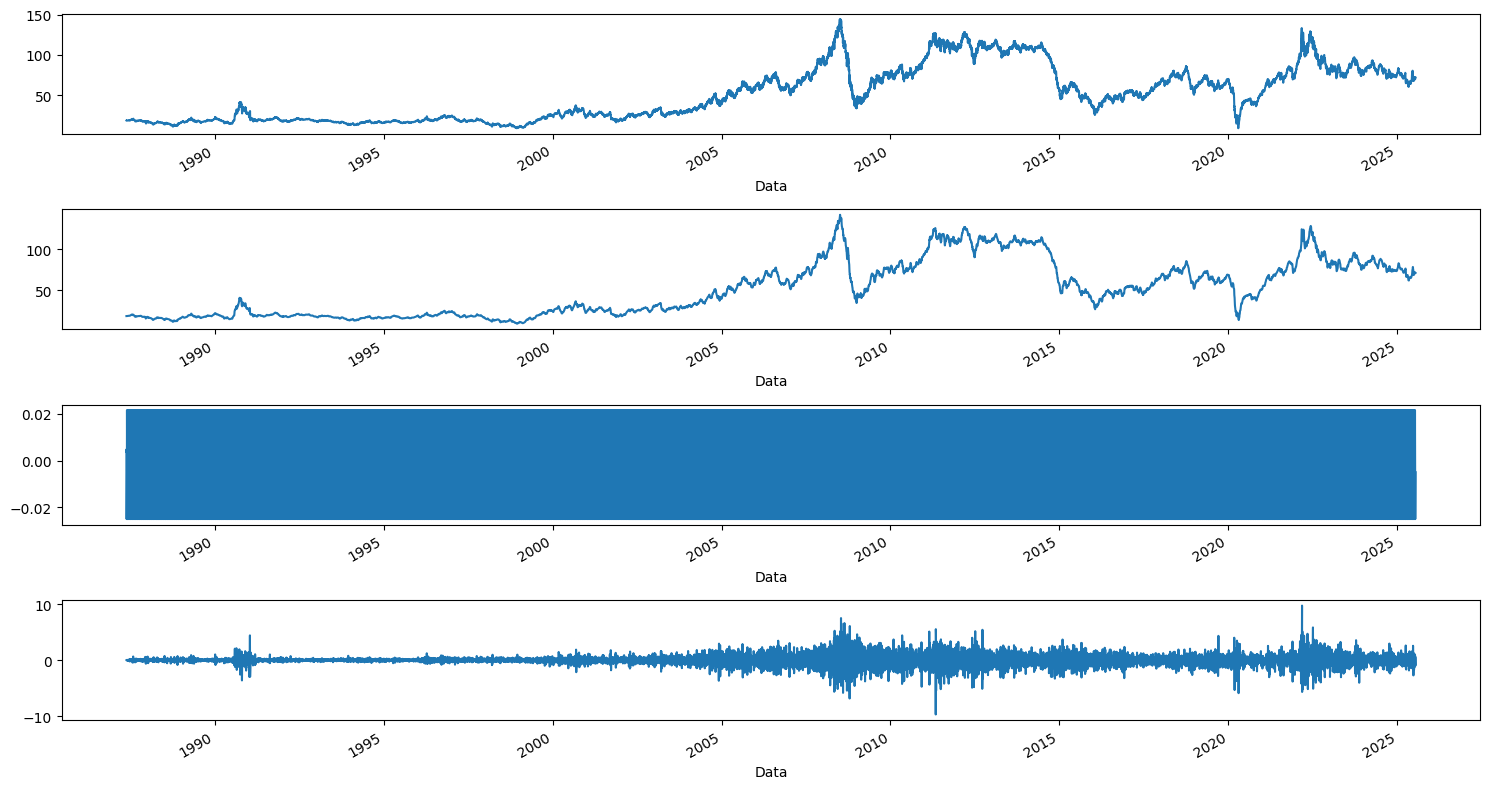

In [100]:
dec = seasonal_decompose(df, period = 5)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15,8))
dec.observed.plot(ax=ax1)
dec.trend.plot(ax=ax2)
dec.seasonal.plot(ax=ax3)
dec.resid.plot(ax=ax4)
plt.tight_layout()

Em seguida, podemos realizar o teste ADF, verificando marcadores estatísticos como o P valor.

De acordo com nosso teste, podemos confirmar que esta não é uma série estacionária.

In [101]:
x = df.Preco.values

ADF_result = adfuller(x)

print('ADF Test')
print(f"Statistical test: {ADF_result[0]}")
print(f"P-value: {ADF_result[1]}")
print('Critical Values:')

for key, value in ADF_result[4].items():
  print(f"\t{key}: {value}")

ADF Test
Statistical test: -2.156731073894688
P-value: 0.22232249878164212
Critical Values:
	1%: -3.4309218954533387
	5%: -2.8617927472683466
	10%: -2.5669045322730057


À partir desta informação podemos iniciar uma série de transformações na série temporal à fim de torná-la estacionária.

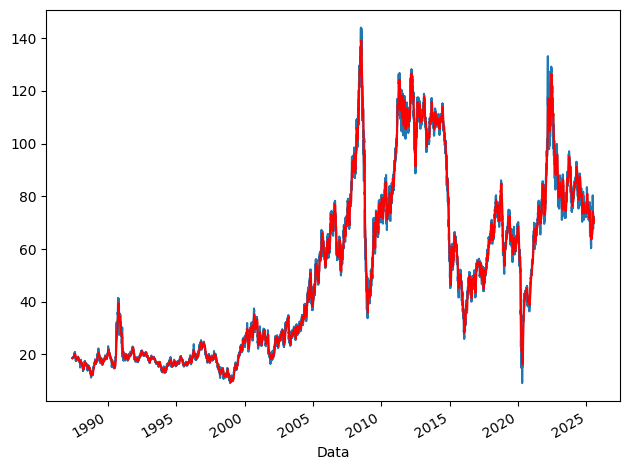

In [102]:
ma12 = df.rolling(12).mean()

f, ax = plt.subplots()

df.plot(ax=ax, legend=False)
ma12.plot(ax=ax, legend=False, color='r')
plt.tight_layout()

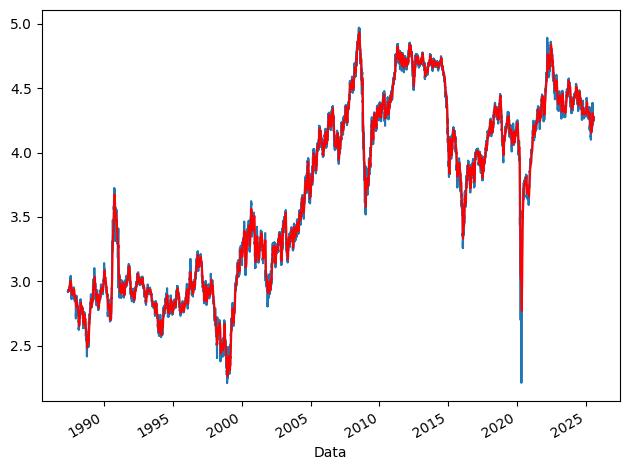

In [103]:
df_log = np.log(df)
ma_log = df_log.rolling(12).mean()

f, ax = plt.subplots()

df_log.plot(ax=ax, legend=False)
ma_log.plot(ax=ax, legend=False, color='r')
plt.tight_layout()

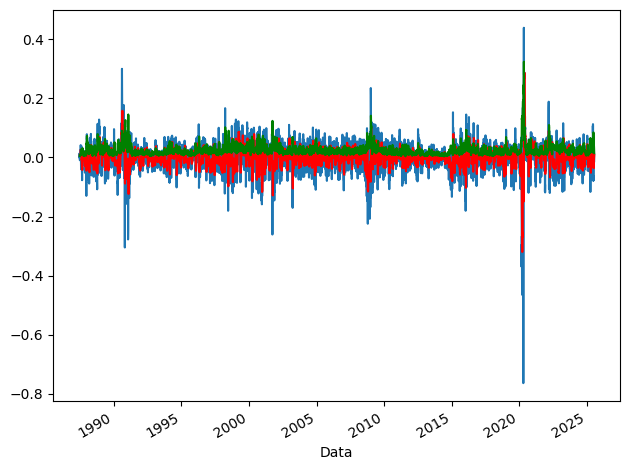

In [104]:
df_s = (df_log - ma_log).dropna()

ma_s = df_s.rolling(12).mean()

std = df_s.rolling(12).std()

f, ax = plt.subplots()
df_s.plot(ax=ax, legend=False)
ma_s.plot(ax=ax, legend=False, color='r')
std.plot(ax=ax, legend=False, color='g')
plt.tight_layout()
plt.show()

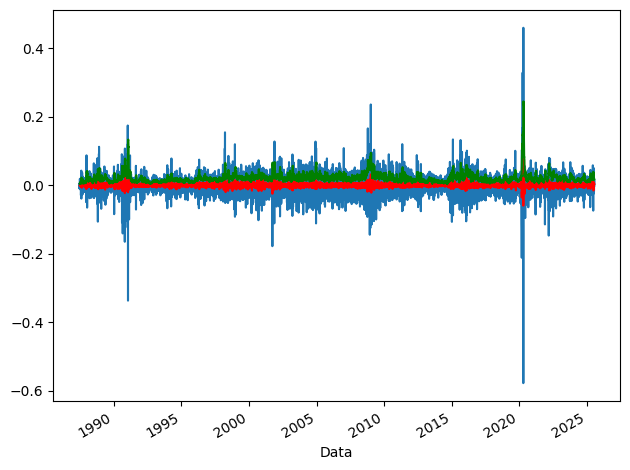

In [105]:
df_diff = df_s.diff(1)

ma_diff = df_diff.rolling(12).mean()

std_diff = df_diff.rolling(12).std()

f, ax = plt.subplots()
df_diff.plot(ax=ax, legend=False)
ma_diff.plot(ax=ax, legend=False, color='r')
std_diff.plot(ax=ax, legend=False, color='g')
plt.tight_layout()
plt.show()

Após a aplicação de médias móveis e diferenciações, chegamos a uma série temporal cujo P Value no teste ADF é 0.0, ou seja: temos uma série estacionária.

In [106]:
x_diff = df_diff.Preco.dropna().values

result_diff = adfuller(x_diff)

print('ADF Test')
print(f"Statistical test: {result_diff[0]}")
print(f"P-value: {result_diff[1]}")
print('Critical Values:')

for key, value in result_diff[4].items():
  print(f"\t{key}: {value}")

ADF Test
Statistical test: -24.864729936047286
P-value: 0.0
Critical Values:
	1%: -3.4309229477051444
	5%: -2.861793212262632
	10%: -2.566904779787856


# Forecasting

Neste momento realizaremos a aplicação do modelo Prophet, desenvolvido pela META.

Iniciamos essa etapa preparando a série temporal para passar pelo modelo.

Devemos ajustar os nomes de columnas e resetar o index para prosseguir com o uso do modelo.

In [112]:
prophet_df = df.reset_index('Data')
prophet_df['Data'] = pd.to_datetime(prophet_df['Data'])
prophet_df[['ds','y']] = prophet_df[['Data','Preco']]
prophet_df = prophet_df.drop(['Data', 'Preco'], axis=1)

prophet_df.head()

,ds,y
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [115]:
train = prophet_df.sample(frac=0.8, random_state=0)
test = prophet_df.drop(train.index)
print(f'training data size : {train.shape}')
print(f'testing data size : {test.shape}')

training data size : (9175, 2)
testing data size : (2294, 2)


In [120]:
model = Prophet(daily_seasonality=True)
model.fit(train)
dataFramefuture = model.make_future_dataframe(periods=365, freq='D')
pred = model.predict(dataFramefuture)
pred.tail()

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6bm16pw9/1yfflo9q.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6bm16pw9/42subpe9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73509', 'data', 'file=/tmp/tmp6bm16pw9/1yfflo9q.json', 'init=/tmp/tmp6bm16pw9/42subpe9.json', 'output', 'file=/tmp/tmp6bm16pw9/prophet_modeln26u7nqz/prophet_model-20250815030832.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
03:08:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
03:08:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
9535,2026-07-17,93.199314,79.184777,108.224845,89.035491,96.807469,0.966334,0.966334,0.966334,-1.222383,...,-0.042364,-0.042364,-0.042364,2.231082,2.231082,2.231082,0.0,0.0,0.0,94.165648
9536,2026-07-18,93.210627,80.516827,108.811854,89.020014,96.838126,1.096491,1.096491,1.096491,-1.222383,...,0.070242,0.070242,0.070242,2.248632,2.248632,2.248632,0.0,0.0,0.0,94.307118
9537,2026-07-19,93.221941,78.863969,108.687214,89.010383,96.895569,0.638484,0.638484,0.638484,-1.222383,...,-0.399293,-0.399293,-0.399293,2.260160,2.260160,2.260160,0.0,0.0,0.0,93.860425
9538,2026-07-20,93.233255,79.952886,108.891603,88.983342,96.936541,1.265265,1.265265,1.265265,-1.222383,...,0.222129,0.222129,0.222129,2.265518,2.265518,2.265518,0.0,0.0,0.0,94.498519
9539,2026-07-21,93.244568,78.650609,109.484454,88.979117,96.963701,1.082871,1.082871,1.082871,-1.222383,...,0.040593,0.040593,0.040593,2.264661,2.264661,2.264661,0.0,0.0,0.0,94.327439


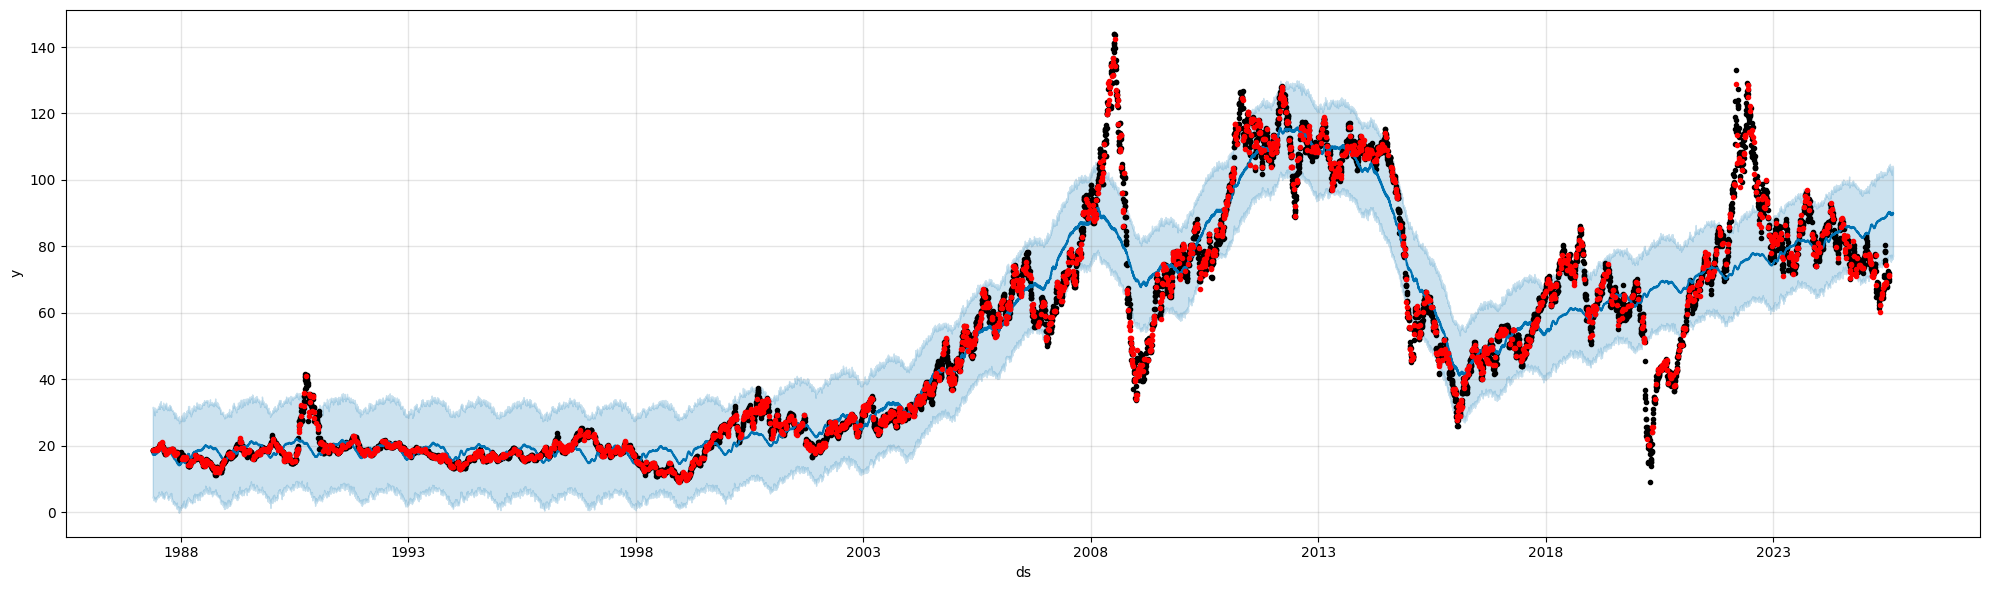

In [117]:
model.plot(pred, figsize=(20,6))
plt.plot(test['ds'], test['y'], '.r')

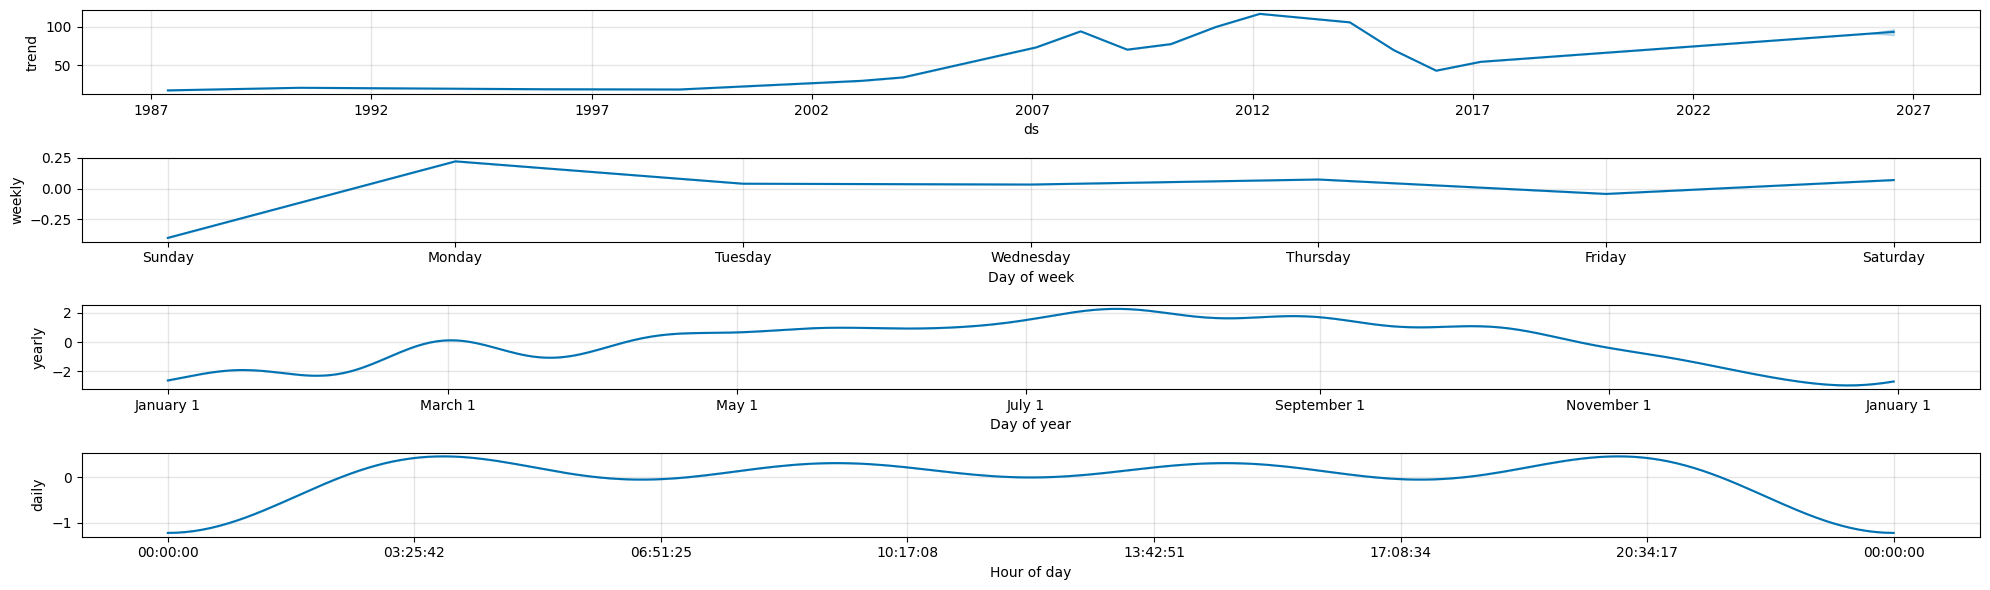

In [121]:
fig2 = model.plot_components(pred, figsize=(20,6))